# 06 — A hypothesis I made, and the control that could not support it

In March 2026 I nominated four target–drug pairs as **silent binders**: ligands that occupy
a pocket without producing activity in the 2012 functional assay. The nomination came from
high interface scores. This notebook runs the control that the nomination needed, on the
same data, and reports what it shows.

It is here rather than deleted because the arc — claim, control, retraction of the claim —
is the point, and because I made the claim.

In [1]:
import sys, os
from pathlib import Path

# Work from the repository root wherever the notebook is launched from.
_root = Path.cwd().resolve()
while not (_root / "src" / "offtarget").exists():
    _root = _root.parent
os.chdir(_root)
sys.path.insert(0, str(_root / "src"))

import pandas as pd
from pathlib import Path
from offtarget.metrics import stratified_auc
from offtarget import figures as F

pd.set_option("display.width", 150)
pairs = pd.read_parquet("data/processed/pairs_audited.parquet")
pairs = pairs[pairs.label.notna()]

CLAIMS = [("MAOA", "Fenoterol"), ("SLC6A4", "Atropine"),
          ("SLC6A4", "Ramipril"), ("SLC6A4", "Benzquinamide")]

## 1. The hypothesis, and why it is reasonable

The ground truth here is **positive–unlabeled**. Lounkine 2012 measured functional activity;
a drug recorded as inactive is a drug that did not move that particular readout at the
concentrations tested. It is not a drug that was shown not to bind.

A neutral antagonist can occupy an orthosteric site and produce no signal in a functional
assay. So "some of these inactives are binders" is a sound prior, and asking a structure
model which ones is a reasonable thing to do. Nothing below argues against the hypothesis.
What follows is about whether *this evidence* can pick the four pairs out.

## 2. What the nomination used

The nomination used ipTM — the interface confidence — with a threshold around 0.97, plus a
low interface PDE. Here is where the four pairs sit.

In [2]:
inact = pairs[pairs.label == "assay_inactive"]
act = pairs[pairs.label == "assay_active"]

rows = []
for tgt, drug in CLAIMS:
    m = pairs[(pairs.Target == tgt) & pairs.drug.str.contains(drug, case=False, na=False)]
    r = m.iloc[0]
    rows.append({"pair": f"{tgt}–{drug}", "ipTM": round(r.iptm, 4),
                 "percentile among confirmed non-binders": round(100 * (inact.iptm < r.iptm).mean(), 1),
                 "percentile among confirmed binders": round(100 * (act.iptm < r.iptm).mean(), 1),
                 "Boltz-2 affinity probability": round(r.affinity_probability, 3)})
pd.DataFrame(rows)

,pair,ipTM,percentile among confirmed non-binders,percentile among confirmed binders,Boltz-2 affinity probability
0,MAOA–Fenoterol,0.9662,50.4,36.7,0.809
1,SLC6A4–Atropine,0.9806,75.2,67.3,0.892
2,SLC6A4–Ramipril,0.9640,48.1,35.4,0.275
3,SLC6A4–Benzquinamide,0.9842,82.9,75.5,0.111


**The candidate I built the most on — MAOA–Fenoterol — is the median confirmed non-binder
on ipTM.** Not an outlier. The middle of the pile.

And Boltz-2's own affinity head disagrees with two of the four: Benzquinamide at 0.111 and
Ramipril at 0.275 are the model saying *unlikely to bind*. The nomination cited the ipTM and
not this.

## 3. The control: what does this metric do where the answer is known?

The nominating threshold is only a nomination if it excludes things. It does not.

In [3]:
n97 = int((inact.iptm > 0.97).sum())
print(f"confirmed non-binders clearing ipTM > 0.97: {n97} of {len(inact)} "
      f"({n97 / len(inact):.0%})")

auc, used = stratified_auc(pairs, "iptm")
print(f"within-target AUC of ipTM on this dataset:  {auc:.3f}  ({used} targets)")

confirmed non-binders clearing ipTM > 0.97: 246 of 561 (44%)


within-target AUC of ipTM on this dataset:  0.486  (34 targets)


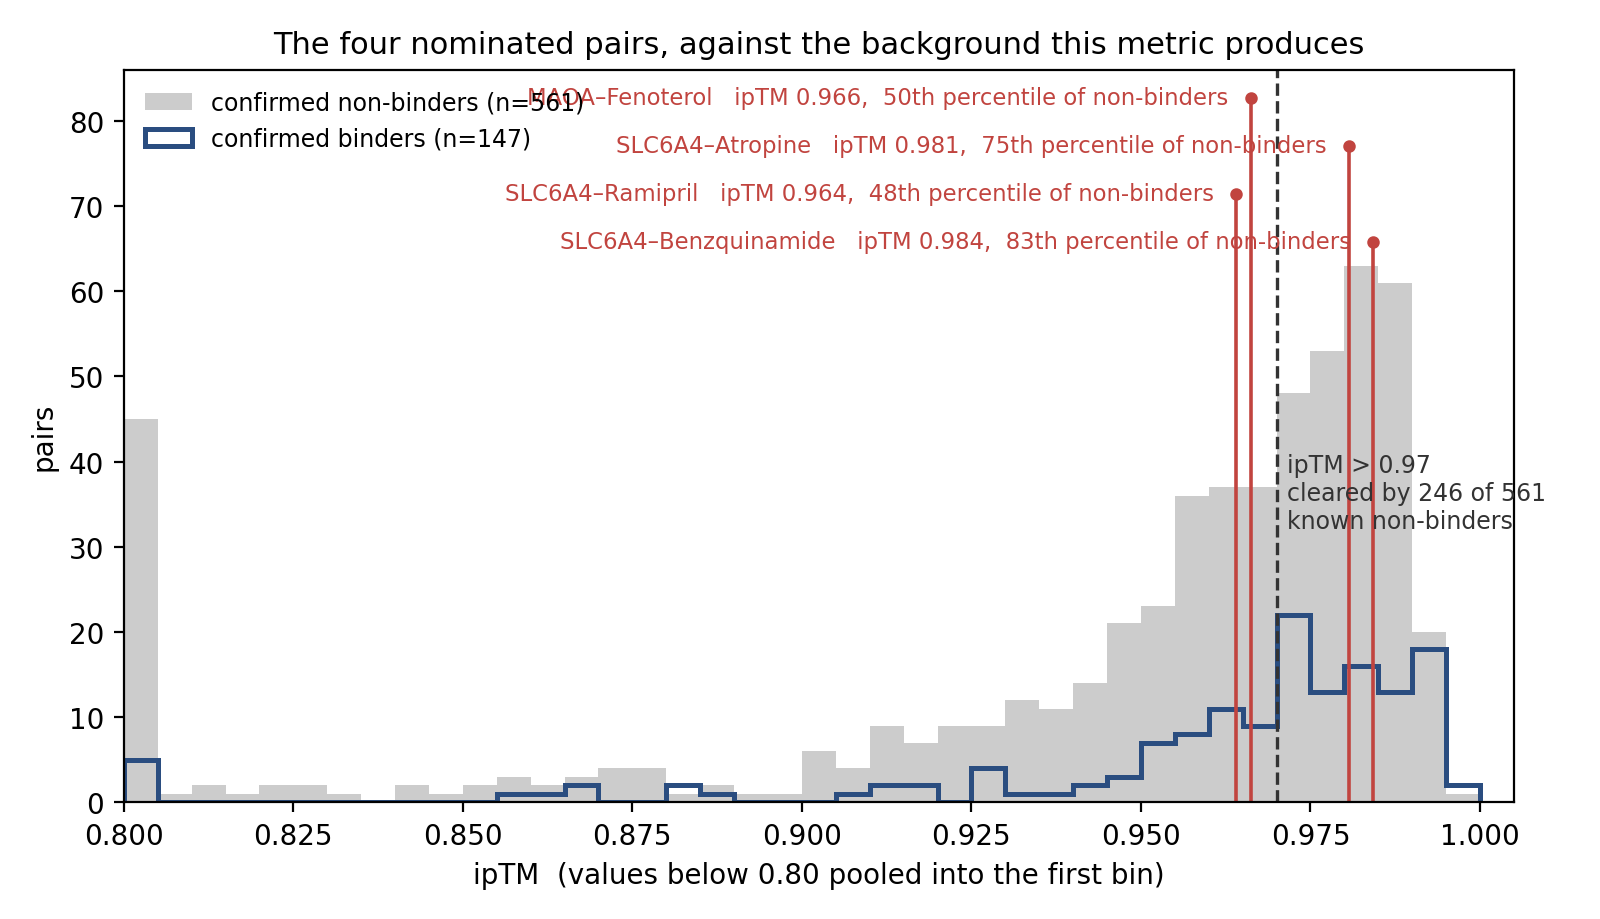

In [4]:
F.claim_background(pairs, CLAIMS, Path("results/figures/fig5_claim_background.png"))
from IPython.display import Image, display
display(Image("results/figures/fig5_claim_background.png"))

**246 of 561 known non-binders — 44% — clear the bar used to nominate four.** A threshold
that half the negatives pass is not selecting anything.

And from notebook 03: the within-target AUC of ipTM on this dataset is **0.486**, with a
bootstrap interval spanning 0.5. The metric that produced the nominations cannot tell a
confirmed binder from a confirmed non-binder.

## 4. The decisive panel

SLC6A4 is the one target here where the ground truth contains confirmed off-target binders.
Lounkine confirms Clemastine, Clobutinol and Bevantolol. Putting them next to my three
SLC6A4 claims and the rest of the panel is the sharpest test available.

In [5]:
LOUNKINE_CONFIRMED = ["Clemastine", "Clobutinol", "Bevantolol"]
s = pairs[pairs.Target == "SLC6A4"].copy()
s["group"] = "other inactive"
for d in LOUNKINE_CONFIRMED:
    s.loc[s.drug.str.contains(d, case=False, na=False), "group"] = "Lounkine-confirmed binder"
for _, d in [c for c in CLAIMS if c[0] == "SLC6A4"]:
    s.loc[s.drug.str.contains(d, case=False, na=False), "group"] = "claimed silent binder"

s.sort_values("iptm", ascending=False)[
    ["drug", "label", "group", "iptm", "affinity_probability"]].round(3)

,drug,label,group,iptm,affinity_probability
692,Clobutinol,assay_active,Lounkine-confirmed binder,0.991,0.998
687,Benzquinamide,assay_inactive,claimed silent binder,0.984,0.111
694,Dyclonine_hydrochloride,assay_inactive,other inactive,0.981,0.685
686,Atropine,assay_inactive,claimed silent binder,0.981,0.892
693,Diphenhydramine,assay_inactive,other inactive,0.977,0.987
691,Clemastine,assay_active,Lounkine-confirmed binder,0.973,0.860
695,Metaraminol,assay_inactive,other inactive,0.973,0.685
688,Bevantolol,assay_active,Lounkine-confirmed binder,0.972,0.792
697,Procyclidine,assay_inactive,other inactive,0.967,0.917
698,Ramipril,assay_inactive,claimed silent binder,0.964,0.275


In [6]:
s.groupby("group")[["iptm", "affinity_probability"]].agg(["mean", "size"]).round(3)

iptm      affinity_probability     
                            mean size                 mean size
group                                                          
Lounkine-confirmed binder  0.979    3                0.883    3
claimed silent binder      0.976    3                0.426    3
other inactive             0.956   10                0.794   10

| | mean ipTM | mean affinity probability |
|---|---|---|
| Lounkine-confirmed SLC6A4 binders (n=3) | 0.979 | **0.883** |
| Claimed silent binders (n=3) | 0.976 | **0.426** |
| Other inactives on the panel (n=10) | 0.956 | 0.794 |

**ipTM does not separate the three groups.** Benzquinamide, one of my claims, ranks second
on the entire panel — above two of the three drugs that actually bind. If the metric ranked
a claim above a confirmed binder, the ranking is not evidence about the claim.

The affinity head *does* separate them, and it ranks my three claims lowest of the three
groups.

## 5. The MAOA panel

Same question on the target behind the strongest claim, using the interface metrics from the
dimer experiment.

In [7]:
dimer = pd.read_parquet("data/processed/dimer_panel.parquet")
maoa = dimer[dimer.Target == "MAOA"].dropna(subset=["Ligand_ipTM", "Interface_PDE"]).copy()
maoa["clears_bar"] = (maoa.Interface_PDE < 1) & (maoa.Ligand_ipTM > 0.9)
print(f"{len(maoa)} drugs modelled against MAOA; "
      f"{int(maoa.clears_bar.sum())} clear iPDE < 1 and ipTM > 0.9")

ranked = maoa.sort_values("Ligand_ipTM", ascending=False).reset_index(drop=True)
ranked["rank"] = ranked.index + 1
ranked[["rank", "drug", "Ligand_ipTM", "Interface_PDE", "clears_bar", "label"]].head(12).round(3)

24 drugs modelled against MAOA; 10 clear iPDE < 1 and ipTM > 0.9


,rank,drug,Ligand_ipTM,Interface_PDE,clears_bar,label
0,1,melatonin,0.978,0.733,True,assay_inactive
1,2,Ephedrine,0.975,0.813,True,assay_inactive
2,3,Fenfluramine_active_compound,0.973,0.837,True,assay_inactive
3,4,Levodopa,0.973,0.805,True,assay_inactive
4,5,Bevantolol,0.972,0.927,True,assay_inactive
5,6,Fenoterol,0.971,0.864,True,assay_inactive
6,7,Phenylephrine,0.971,0.921,True,assay_inactive
7,8,Pseudoephedrine,0.970,0.911,True,assay_inactive
8,9,Metaraminol,0.969,0.872,True,assay_inactive
9,10,Fenfluramine,0.964,0.919,True,assay_inactive


**Fenoterol ranks 6th of 24**, behind melatonin, ephedrine, fenfluramine, levodopa and
bevantolol. Ten of the 24 clear the "crystal-structure quality" bar the nomination cited,
including levodopa and acetaminophen. The bar admits paracetamol.

## 6. And the construct

All three SLC6A4 claims were run against the input audited in notebook 02: the canonical
sequence followed by 55 residues of purification scaffold — a thrombin site, twin Strep-tag,
GS linkers and His12. The claims were made from a model input that is not the human protein
as it exists in a cell.

In [8]:
import yaml
from offtarget.constructs import find_construct_tags
cfg = yaml.safe_load(Path("inputs/targets.yaml").read_text())
seq = cfg["targets"]["SLC6A4"]["arms"]["pdb"]["sequence"]
print(f"input length {len(seq)}, canonical P31645 length "
      f"{cfg['targets']['SLC6A4']['canonical_length']}")
print("scaffold motifs:", sorted({t.name for t in find_construct_tags(seq)}))

input length 685, canonical P31645 length 630
scaffold motifs: ['GS-linker', 'His-tag', 'Strep-tag', 'thrombin']


## 7. Where this leaves the hypothesis

The 2012 inactives are positive–unlabeled, so I asked whether any of them were silent
binders — occupying the pocket without functional activity. Boltz-2 gave four candidates
with high interface scores. Then I asked what those scores do on pairs where the answer is
known: within-target AUC 0.486. The metric that nominated them cannot separate a confirmed
binder from a confirmed non-binder, 44% of known non-binders clear the same threshold, and
on the one target that has confirmed off-target binders the nominations rank above two of
them.

The hypothesis may still be right. **This evidence cannot establish it, and the experiment
that could is a binding assay, not a better score.** A radioligand displacement or SPR
measurement on those four pairs would settle it in an afternoon; no amount of further
modelling will.

Nothing in this repository presents those four pairs as findings, and the downstream
therapeutic proposal built on one of them in the March 2026 deck is not carried anywhere in
this repository, including in an appendix.